## CGM Metrics Roadmap

This notebook will progressively compute and analyze a comprehensive set of CGM metrics, following best practices for clarity and reproducibility:

- **Phase 1:** Basic metrics (mean, std, CV, min, max, range)
- **Phase 2:** Variability metrics (MAGE, CONGA-2, GFI)
- **Phase 3:** Phenotype metrics (TU100, AO140, time above 140, time in range)
- **Phase 4:** Poincaré plot metrics (SD1, SD2)
- **Phase 5:** Entropy (Sample Entropy, Approximate Entropy)
- **Phase 6:** DFA (Detrended Fluctuation Analysis)
- **Phase 7:** Merge with clinical data and PCA

We will build up the analysis step by step, saving results and tables for each phase.

# CGM Metrics Analysis

In this notebook, we compute key metrics for Continuous Glucose Monitoring (CGM) data using the cleaned and interpolated dataset.

The dataset has been preprocessed to:

- Remove duplicates
- Handle missing values
- Apply quality filtering
- Interpolate glucose values

We now compute several metrics commonly used in CGM analysis, including:

- Mean glucose
- Standard deviation
- Coefficient of variation (CV)
- Time under 100 mg/dL (TU100)
- Area over 140 mg/dL (AO140)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load all interpolated patient files from processed folder
patients_interp = {}
input_path = '../data/processed/interpolated'
for fname in os.listdir(input_path):
    if fname.endswith('.csv') and fname.startswith('case_'):
        case_id = int(fname.split('_')[1].split('.')[0])
        df = pd.read_csv(os.path.join(input_path, fname))
        patients_interp[case_id] = df
print(f'Loaded {len(patients_interp)} patients.')

Loaded 114 patients.


In [2]:
# Step 2: Basic metrics
def compute_basic_metrics(df):
    glucose = df['glucose']
    mean = glucose.mean()
    std = glucose.std()
    cv = std / mean * 100
    return {
        'mean': mean,
        'std': std,
        'cv': cv
    }

In [3]:
# Step 3: TU100
def compute_tu100(df):
    glucose = df['glucose']
    tu100 = (glucose < 100).sum() / len(glucose) * 100
    return tu100

In [4]:
# Step 4: AO140
def compute_ao140(df):
    glucose = df['glucose']
    excess = glucose[glucose > 140] - 140
    ao140 = excess.sum()
    return ao140

In [5]:
# Step 5: Apply to all patients
metrics = []
for case_id, df in patients_interp.items():
    basic = compute_basic_metrics(df)
    tu100 = compute_tu100(df)
    ao140 = compute_ao140(df)
    metrics.append({
        'case_id': case_id,
        'mean': basic['mean'],
        'std': basic['std'],
        'cv': basic['cv'],
        'tu100': tu100,
        'ao140': ao140
    })
metrics_df = pd.DataFrame(metrics)
metrics_df.head()

,case_id,mean,std,cv,tu100,ao140
0,39,97.928819,9.459393,9.659457,70.486111,0.0
1,98,96.887153,17.363312,17.921171,60.763889,18.0
2,124,94.465278,10.254879,10.855713,82.986111,0.0
3,54,101.071181,22.184434,21.949317,44.097222,62.5
4,89,99.819444,15.594671,15.622879,55.555556,8.0


In [6]:
# Step 6: Quick exploration
metrics_df.describe()

,case_id,mean,std,cv,tu100,ao140
count,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000
mean,93.728070,102.756046,14.618263,14.177008,49.384747,247.666667
std,59.073868,13.229812,5.601092,5.089540,28.685023,755.017672
min,1.000000,78.621528,4.008176,4.262206,0.000000,0.000000
25%,43.250000,94.229601,10.269899,10.215460,27.170139,0.000000
50%,86.500000,100.952257,14.472090,14.125269,51.041667,0.000000
75%,139.750000,108.687066,18.565209,17.173470,72.829861,110.125000
max,206.000000,158.125000,29.706186,30.968440,99.305556,6199.000000


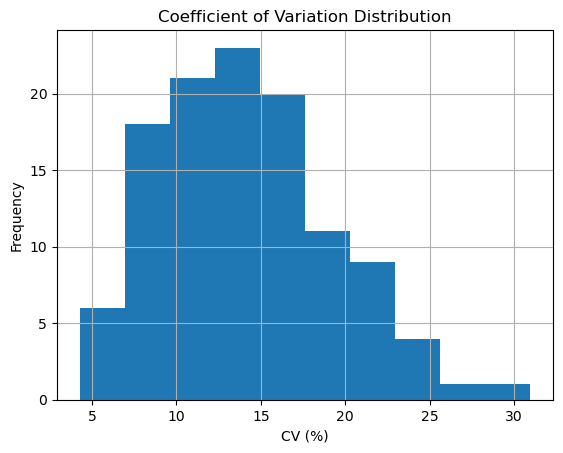

In [8]:
# --- Phase 1: Basic and Range Metrics ---
def compute_basic_metrics(df):
    glucose = df['glucose']
    mean = glucose.mean()
    std = glucose.std()
    cv = std / mean * 100
    min_glucose = glucose.min()
    max_glucose = glucose.max()
    glucose_range = max_glucose - min_glucose
    return {
        'mean': mean,
        'std': std,
        'cv': cv,
        'min_glucose': min_glucose,
        'max_glucose': max_glucose,
        'range': glucose_range
    }

# --- Phase 2: Variability Metrics ---
def compute_mage(df, threshold_std=1):
    glucose = df['glucose']
    std = glucose.std()
    threshold = threshold_std * std
    diffs = glucose.diff().abs()
    excursions = diffs[diffs > threshold]
    return excursions.mean()

def compute_conga(df, n=24):
    glucose = df['glucose']
    diff = glucose - glucose.shift(n)
    return diff.std()

def compute_gfi(df):
    glucose = df['glucose']
    return glucose.diff().abs().mean()

# --- Phase 3: Phenotype Metrics ---
def compute_tu100(df):
    glucose = df['glucose']
    tu100 = (glucose < 100).sum() / len(glucose) * 100
    return tu100

def compute_ao140(df):
    glucose = df['glucose']
    excess = glucose[glucose > 140] - 140
    ao140 = excess.sum()
    return ao140

def compute_time_above_140(df):
    glucose = df['glucose']
    return (glucose > 140).mean() * 100

def compute_time_in_range(df):
    glucose = df['glucose']
    return ((glucose >= 70) & (glucose <= 140)).mean() * 100

# --- Phase 4: Poincaré Plot Metrics ---
def poincare(df):
    x1 = df['glucose'][:-1]
    x2 = df['glucose'][1:]
    diff = x2.values - x1.values
    sd1 = np.std(diff) / np.sqrt(2)
    sd2 = np.std(x1.values + x2.values) / np.sqrt(2)
    return sd1, sd2

# --- Phase 5: Entropy (Sample Entropy) ---
def sampen(series, m=2, r=None):
    x = series.values
    if r is None:
        r = 0.2 * np.std(x)
    def _phi(m):
        N = len(x)
        return np.sum([
            np.sum(np.abs(x[i:i+m] - x[j:j+m]) <= r)
            for i in range(N - m)
            for j in range(i+1, N - m)
        ])
    return -np.log(_phi(m+1) / _phi(m))

# --- Apply all metrics to all patients ---
metrics = []
for case_id, df in patients_interp.items():
    basic = compute_basic_metrics(df)
    mage = compute_mage(df)
    conga2 = compute_conga(df, n=24)
    gfi = compute_gfi(df)
    tu100 = compute_tu100(df)
    ao140 = compute_ao140(df)
    time_above_140 = compute_time_above_140(df)
    time_in_range = compute_time_in_range(df)
    sd1, sd2 = poincare(df)
    try:
        entropy = sampen(df['glucose'])
    except Exception:
        entropy = np.nan
    metrics.append({
        'case_id': case_id,
        **basic,
        'mage': mage,
        'conga2': conga2,
        'gfi': gfi,
        'tu100': tu100,
        'ao140': ao140,
        'time_above_140': time_above_140,
        'time_in_range': time_in_range,
        'sd1': sd1,
        'sd2': sd2,
        'sampen': entropy
    })
metrics_df = pd.DataFrame(metrics)
metrics_df.head()

# Save metrics table
metrics_df.to_csv('../results/tables/metrics_summary.csv', index=False)

# Quick exploration
metrics_df.describe()

# Visualize CV distribution
metrics_df['cv'].hist()
plt.title('Coefficient of Variation Distribution')
plt.xlabel('CV (%)')
plt.ylabel('Frequency')
plt.show()

## Merge with Clinical Data and Group Analysis

We now merge the computed metrics with the clinical dataset to enable group comparisons (e.g., DM2 vs no DM2).

In [33]:
# Load clinical data 
clinical_cols = ['case_id', 'gender', 'age', 'BMI', 'glycaemia', 'HbA1c', 'follow_up', 'T2DM']
clinical = pd.read_csv(
    "../data/raw/clinical_data.txt",
    sep=r"\s+",
    engine="python",
    skiprows=1,
    names=clinical_cols,
    na_values=['NA'],
)
clinical['case_id'] = clinical['case_id'].astype(str).str.replace('"', '', regex=False).astype(int)
clinical['T2DM'] = clinical['T2DM'].astype(str).str.upper()
metrics_df['case_id'] = metrics_df['case_id'].astype(int)

full_df = metrics_df.merge(clinical, on='case_id', how='inner')
print('metrics_df shape:', metrics_df.shape)
print('clinical shape:', clinical.shape)
print('merged shape:', full_df.shape)
print(full_df[['case_id', 'gender', 'age', 'T2DM']].head())

metrics_df shape: (114, 17)
clinical shape: (208, 8)
merged shape: (113, 24)
   case_id  gender  age   T2DM
0       39       1   59  FALSE
1       98       1   56  FALSE
2      124       1   65  FALSE
3       54       1   63  FALSE
4       89       1   63  FALSE


In [27]:
# Group analysis: DM2 vs no DM2
full_df['DM2'] = full_df['T2DM'].map({'TRUE': 1, 'FALSE': 0})
dm2 = full_df[full_df['DM2'] == 1]
no_dm2 = full_df[full_df['DM2'] == 0]
print('DM2 patients:', len(dm2))
print('No DM2 patients:', len(no_dm2))
dm2.describe(), no_dm2.describe()

DM2 patients: 8
No DM2 patients: 105


(          case_id        mean        std         cv  min_glucose  max_glucose  \
 count    8.000000    8.000000   8.000000   8.000000      8.00000     8.000000   
 mean   103.500000  109.030165  15.319815  13.880460     83.18750   150.312500   
 std     77.404319   13.894102   5.682821   4.170618     14.05331    25.564956   
 min     23.000000   84.230903   8.045254   9.551428     60.00000   102.000000   
 25%     27.250000  103.522569  12.397328  10.813498     70.87500   146.500000   
 50%    104.500000  110.305556  13.799664  11.974036     88.25000   152.250000   
 75%    165.500000  117.075521  16.973943  17.065671     94.87500   155.500000   
 max    195.000000  129.680556  26.321558  20.297228     97.00000   193.000000   
 
            range  mage     conga2       gfi  ...       sd1        sd2  \
 count   8.000000   0.0   8.000000  8.000000  ...  8.000000   8.000000   
 mean   67.125000   NaN  20.091431  1.400261  ...  1.342648  21.554369   
 std    22.655416   NaN   8.177070  0.

## Individual and Aggregate Glucose Curves

We now visualize individual and aggregate glucose curves, including group comparisons (DM2 vs no DM2).

In [11]:
# Individual glucose curve

def plot_patient(df, case_id):
    plt.figure(figsize=(10,4))
    plt.plot(df["time"], df["glucose"])
    plt.axhline(70, linestyle="--", color="orange")
    plt.axhline(140, linestyle="--", color="red")
    plt.title(f"Patient {case_id}")
    plt.xlabel("Time")
    plt.ylabel("Glucose")
    plt.show()

# Example: plot_patient(patients_interp[1], 1)

In [12]:
# Aggregate glucose curves (all patients)
def aggregate_curve(patients_dict):
    all_curves = np.array([df["glucose"].values for df in patients_dict.values()])
    median = np.median(all_curves, axis=0)
    p25 = np.percentile(all_curves, 25, axis=0)
    p75 = np.percentile(all_curves, 75, axis=0)
    plt.plot(median, label='Median')
    plt.fill_between(range(len(median)), p25, p75, alpha=0.3, label='IQR')
    plt.title("Median glucose curve with IQR")
    plt.xlabel("Time point")
    plt.ylabel("Glucose")
    plt.legend()
    plt.show()

# Example: aggregate_curve(patients_interp)

DM2 group:


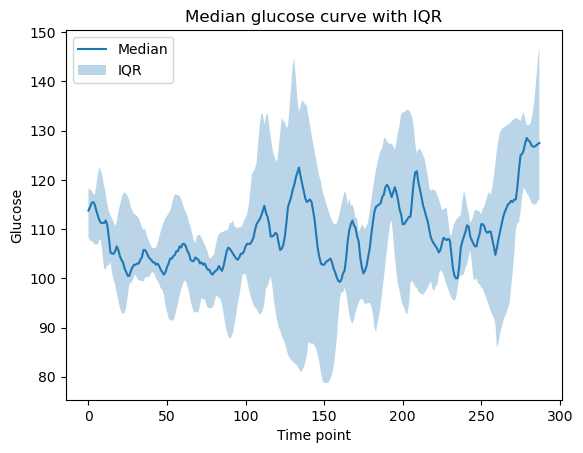

No DM2 group:


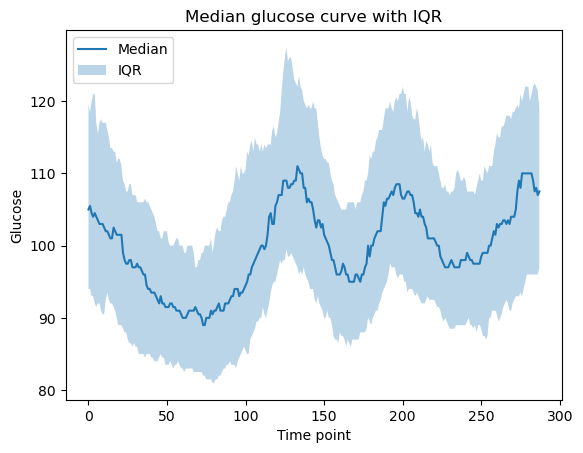

In [28]:
# Aggregate curves by group (DM2 vs no DM2)
dm2_cases = full_df.loc[full_df['DM2'] == 1, 'case_id'].tolist()
no_dm2_cases = full_df.loc[full_df['DM2'] == 0, 'case_id'].tolist()

print("DM2 group:")
aggregate_curve({case_id: patients_interp[case_id] for case_id in dm2_cases if case_id in patients_interp})
print("No DM2 group:")
aggregate_curve({case_id: patients_interp[case_id] for case_id in no_dm2_cases if case_id in patients_interp})

## PCA of CGM Metrics

We now perform PCA on the computed metrics and visualize the results, colored by DM2 diagnosis.

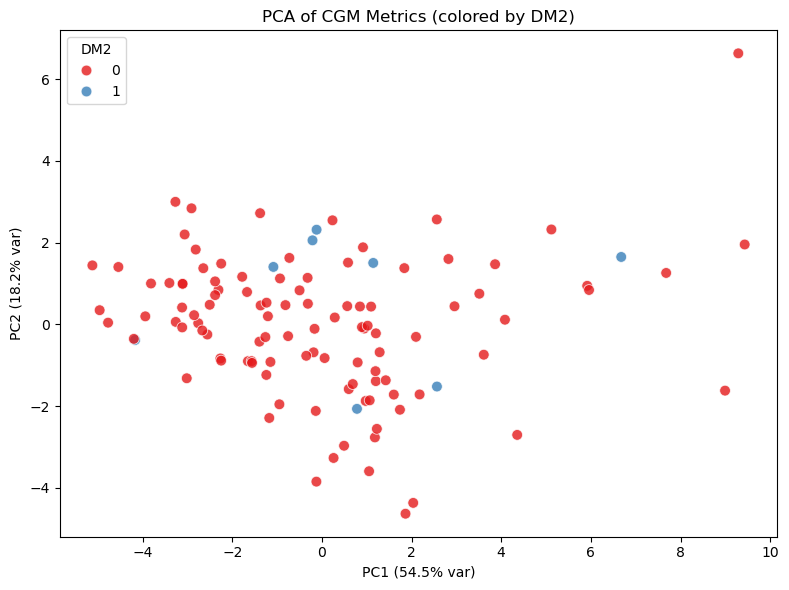

In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Select only CGM-derived numeric metrics for PCA
exclude_cols = ['case_id', 'DM2', 'gender', 'age', 'BMI', 'glycaemia', 'HbA1c', 'follow_up', 'T2DM']
metric_cols = [col for col in full_df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(full_df[col])]

pca_input = full_df[metric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
data_std = StandardScaler().fit_transform(pca_input)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_std)
full_df['PCA1'] = pca_result[:, 0]
full_df['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=full_df, x='PCA1', y='PCA2', hue='DM2', palette='Set1', s=60, alpha=0.8)
plt.title('PCA of CGM Metrics (colored by DM2)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)')
plt.legend(title='DM2')
plt.tight_layout()
plt.show()

## Detrended Fluctuation Analysis (DFA)

DFA is a method for quantifying long-range correlations in time series. Here, we compute DFA exponents for each patient and compare between DM2 and non-DM2 groups.

/tmp/ipykernel_3304/1953697338.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x='DM2', y='dfa_exp', palette='Set2')


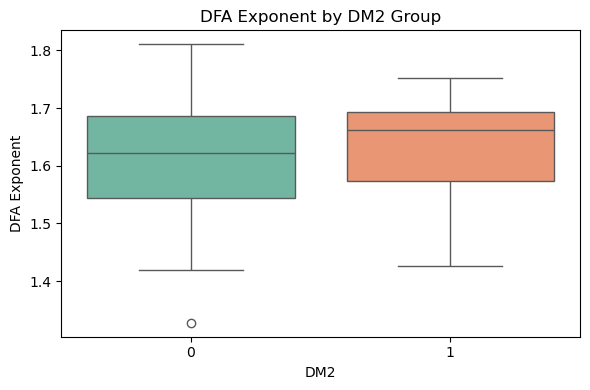

In [32]:
# Compute DFA for each patient and add to full_df
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.dfa import simple_dfa

dfa_results = []
for case_id, df in patients_interp.items():
    try:
        dfa_exp = simple_dfa(df['glucose'].values)
    except Exception:
        dfa_exp = np.nan
    dfa_results.append({'case_id': case_id, 'dfa_exp': dfa_exp})
dfa_df = pd.DataFrame(dfa_results)

full_df = full_df.merge(dfa_df, on='case_id', how='left')

plt.figure(figsize=(6, 4))
sns.boxplot(data=full_df, x='DM2', y='dfa_exp', palette='Set2')
plt.title('DFA Exponent by DM2 Group')
plt.xlabel('DM2')
plt.ylabel('DFA Exponent')
plt.tight_layout()
plt.show()

In [55]:
# Full DFA: returns exponent and log-log curve
from src.dfa import simple_dfa
import matplotlib.pyplot as plt
import numpy as np

def dfa_full(signal, min_window=4, max_window=None, n_windows=12, plot=True):
    values = np.asarray(signal, dtype=float)
    values = values[np.isfinite(values)]
    if values.size < min_window * 4:
        return np.nan, None, None
    profile = np.cumsum(values - values.mean())
    upper_window = max_window or max(min_window + 1, values.size // 4)
    if upper_window <= min_window:
        return np.nan, None, None
    window_sizes = np.unique(
        np.logspace(
            np.log10(min_window),
            np.log10(upper_window),
            num=n_windows,
        ).astype(int)
    )
    fluctuations = []
    valid_windows = []
    for window in window_sizes:
        if window < 2:
            continue
        n_segments = values.size // window
        if n_segments < 2:
            continue
        trimmed = profile[: n_segments * window]
        segments = trimmed.reshape(n_segments, window)
        x_axis = np.arange(window)
        rms_values = []
        for segment in segments:
            coeffs = np.polyfit(x_axis, segment, deg=1)
            trend = np.polyval(coeffs, x_axis)
            rms_values.append(np.sqrt(np.mean((segment - trend) ** 2)))
        fluctuation = np.sqrt(np.mean(np.square(rms_values)))
        if np.isfinite(fluctuation) and fluctuation > 0:
            valid_windows.append(window)
            fluctuations.append(fluctuation)
    if len(valid_windows) < 2:
        return np.nan, None, None
    log_windows = np.log(valid_windows)
    log_fluct = np.log(fluctuations)
    slope, intercept = np.polyfit(log_windows, log_fluct, deg=1)
    if plot:
        plt.figure(figsize=(5,3))
        plt.plot(log_windows, log_fluct, 'o-', label='log-log curve')
        plt.plot(log_windows, slope*log_windows + intercept, '--', label=f'Fit (alpha={slope:.2f})')
        plt.xlabel('log(window size)')
        plt.ylabel('log(fluctuation)')
        plt.title('DFA log-log curve')
        plt.legend()
        plt.tight_layout()
        plt.show()
    return float(slope), valid_windows, fluctuations



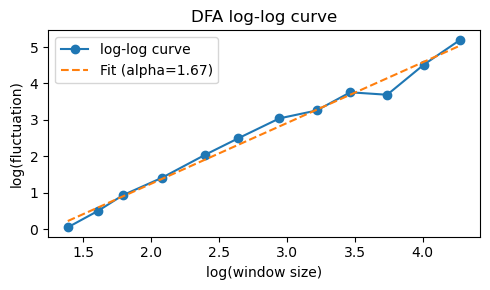

Exponente DFA (alpha): 1.667
Tamaños de ventana: [np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(11), np.int64(14), np.int64(19), np.int64(25), np.int64(32), np.int64(42), np.int64(55), np.int64(72)]
Fluctuaciones: [np.float64(1.0514540197058309), np.float64(1.6541282752184545), np.float64(2.539584106475393), np.float64(4.099841105451173), np.float64(7.711560537594456), np.float64(12.069763686477451), np.float64(20.946368367794044), np.float64(26.00709185152055), np.float64(42.85245806044686), np.float64(40.06366784010629), np.float64(91.48588599066983), np.float64(181.54405475974596)]


In [56]:
# Example of using complete DFA with one patient
alpha, win, fluc = dfa_full(patients_interp[1]['glucose'].values)
print(f"Exponente DFA (alpha): {alpha:.3f}")
print("Tamaños de ventana:", win)
print("Fluctuaciones:", fluc)


## DFA applied to all patients and technical details

Next, the DFA exponent is computed for all patients and integrated into the metrics dataset. In addition, a note on DFA versions is included, and long gaps in the data are detected and incorporated into the final dataset. Finally, the complete result is saved as a CSV file.

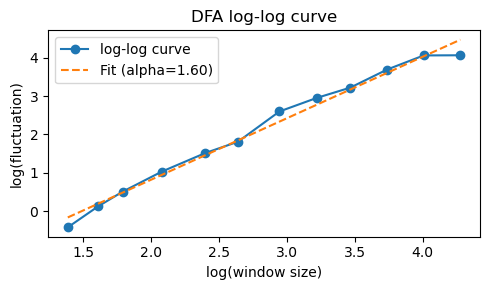

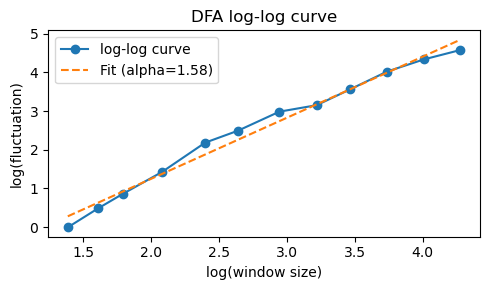

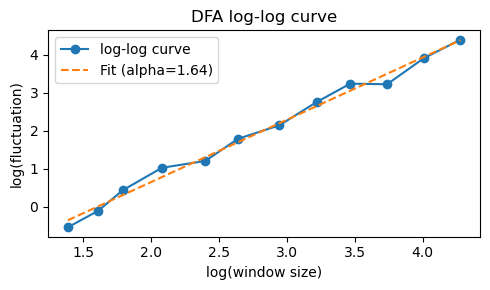

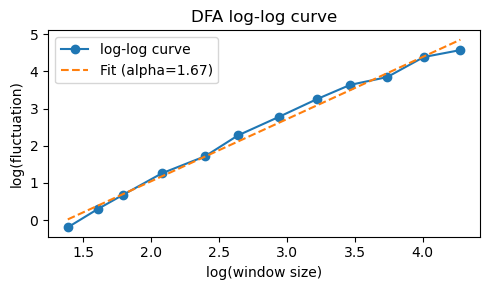

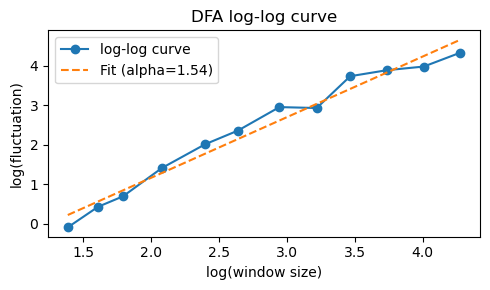

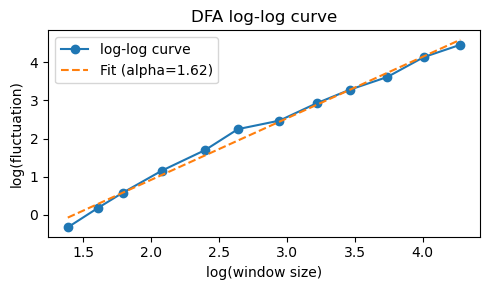

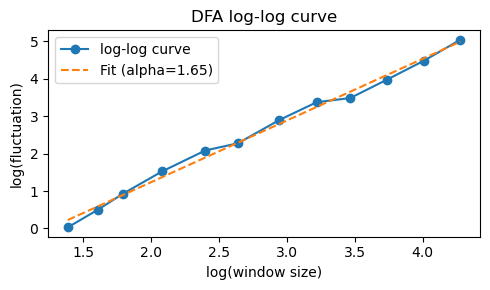

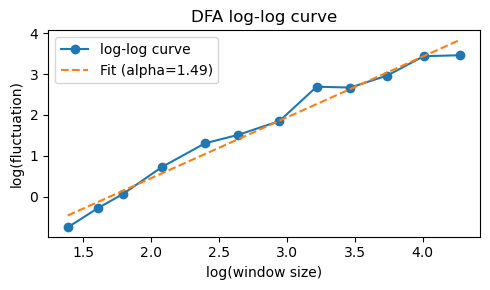

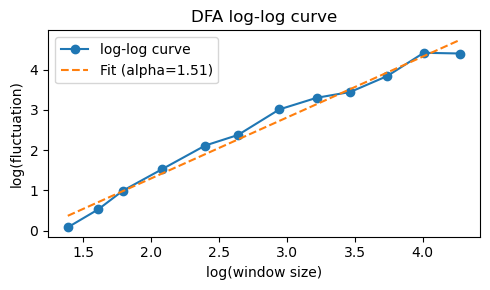

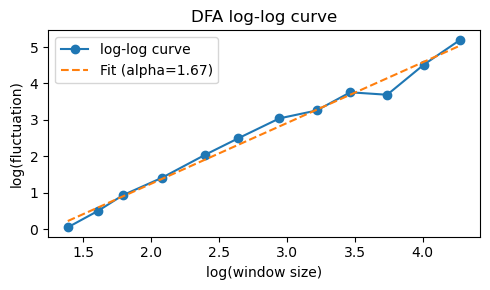

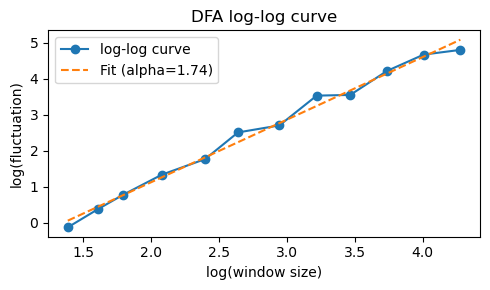

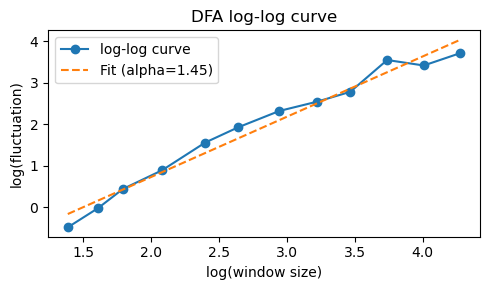

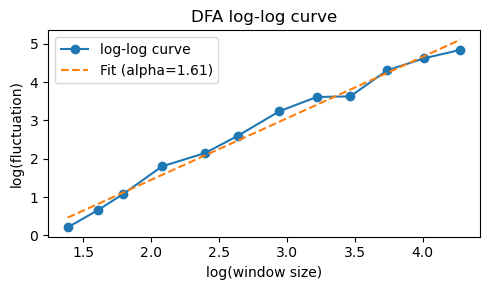

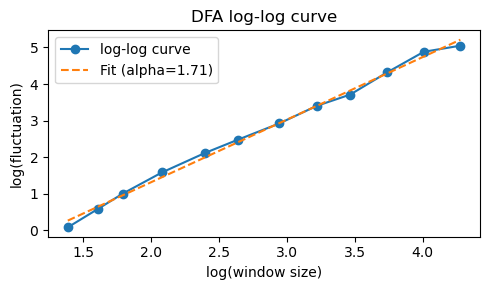

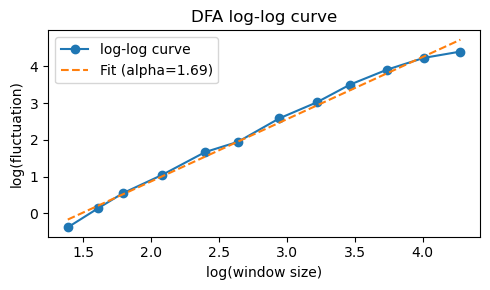

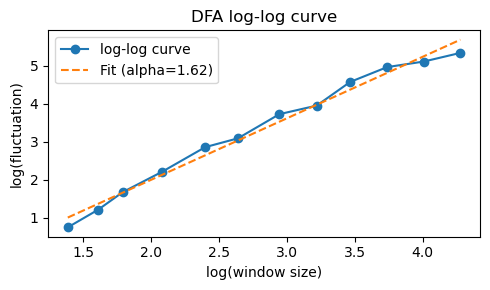

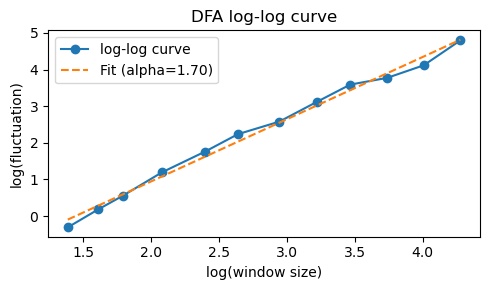

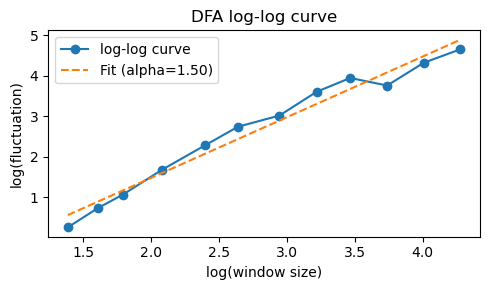

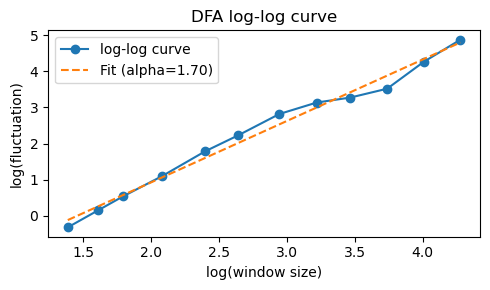

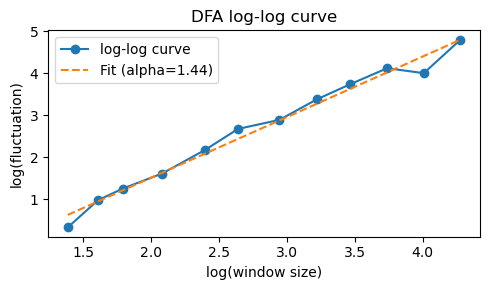

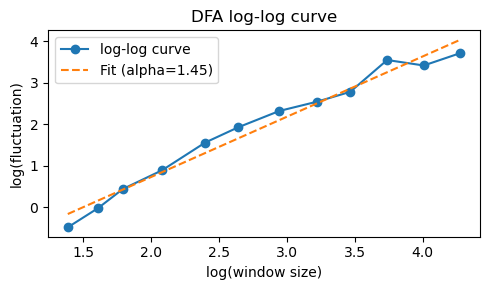

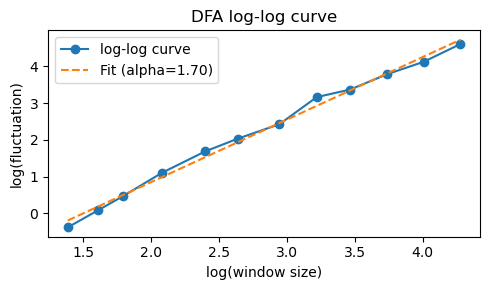

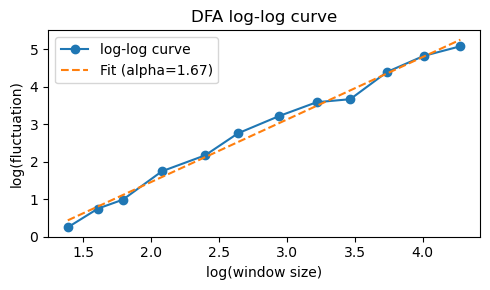

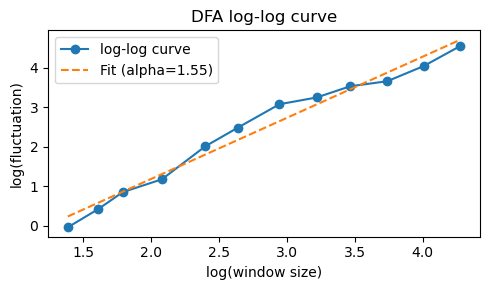

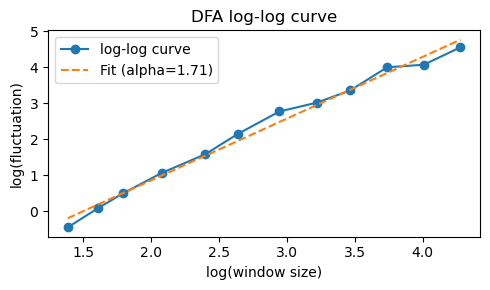

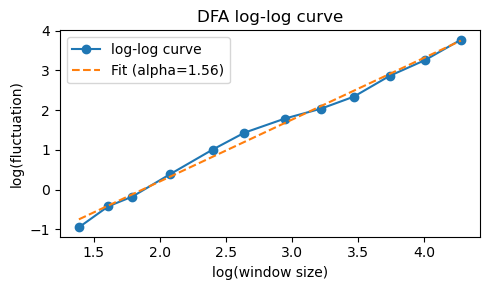

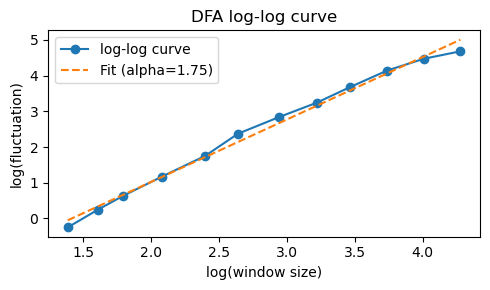

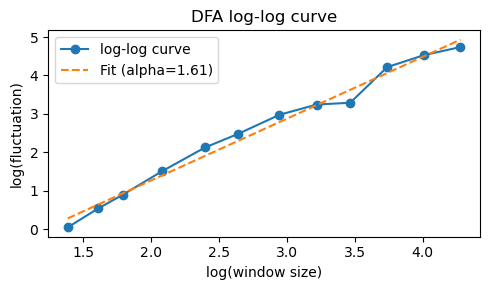

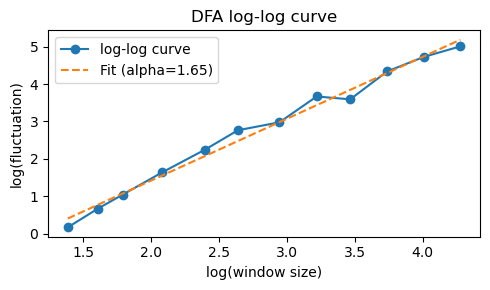

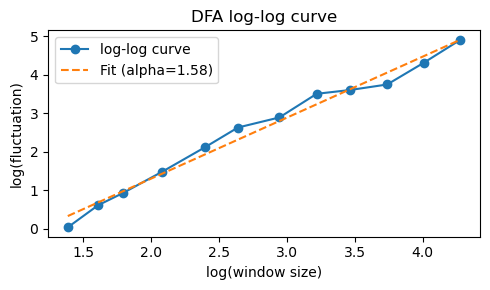

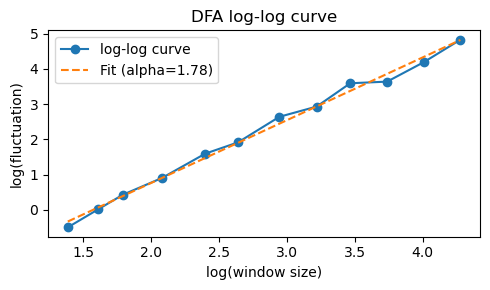

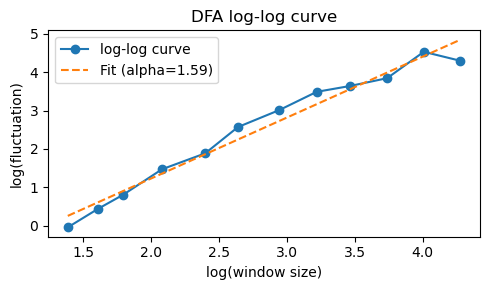

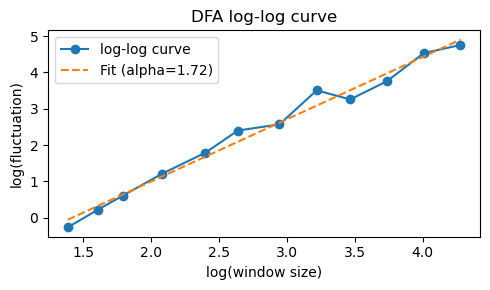

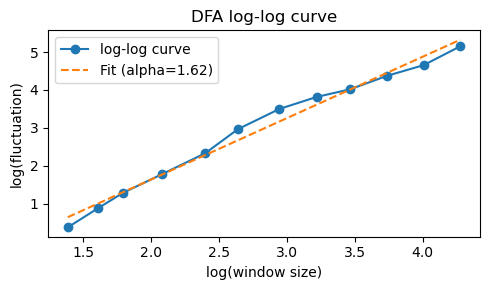

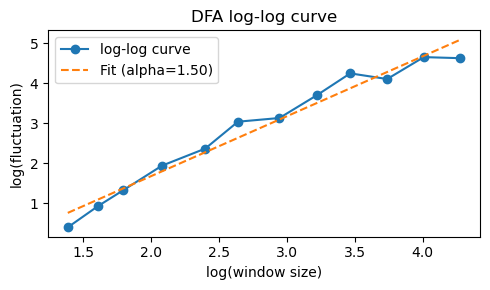

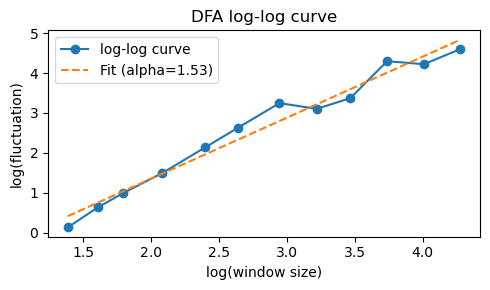

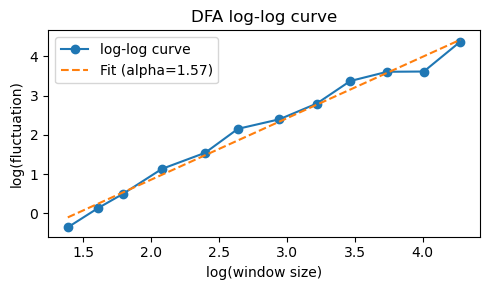

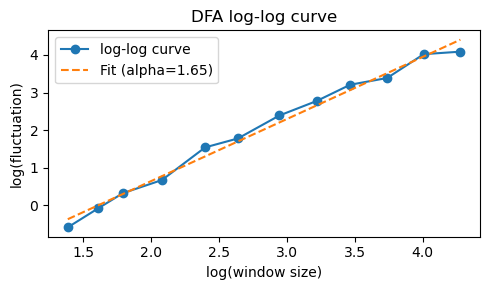

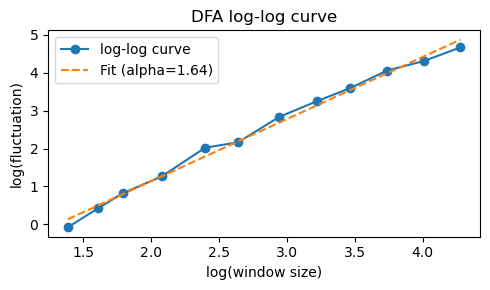

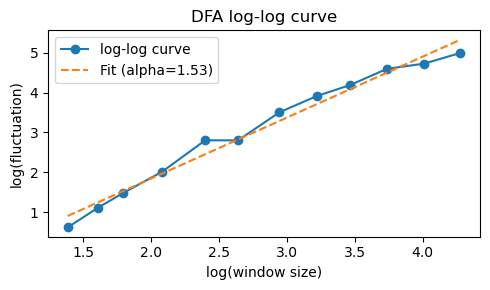

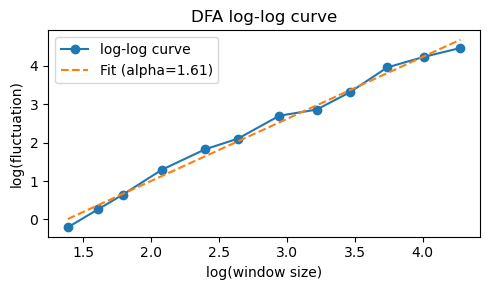

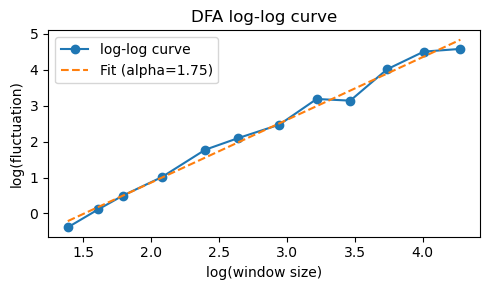

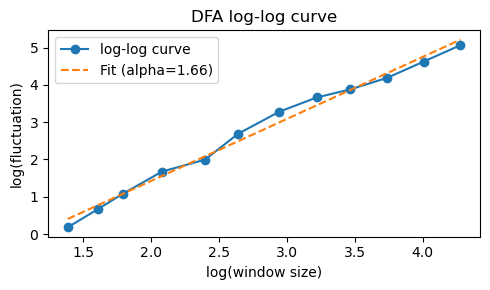

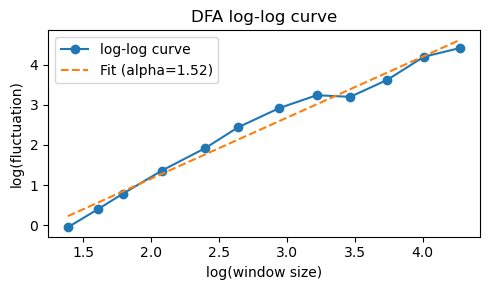

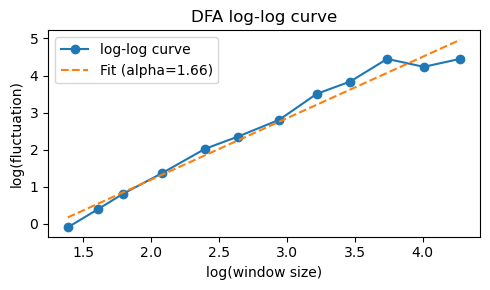

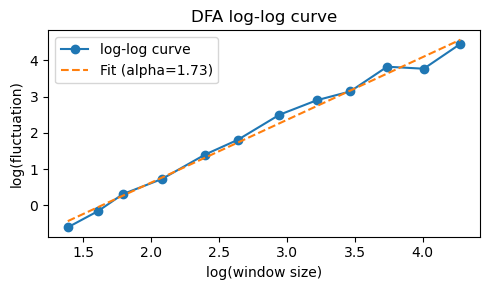

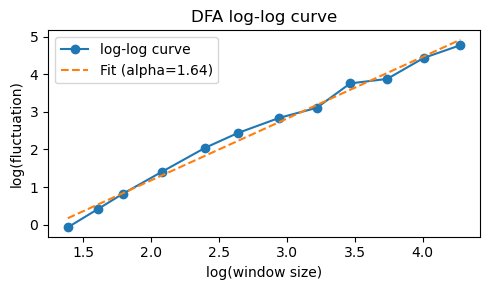

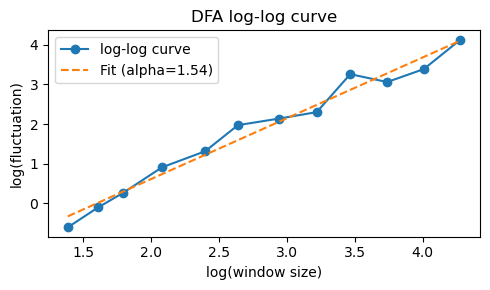

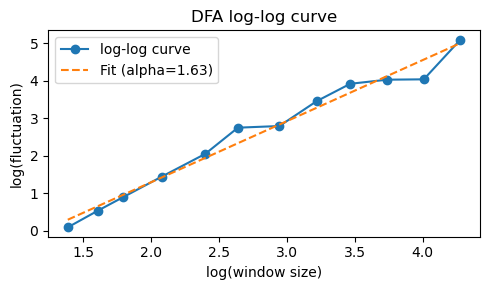

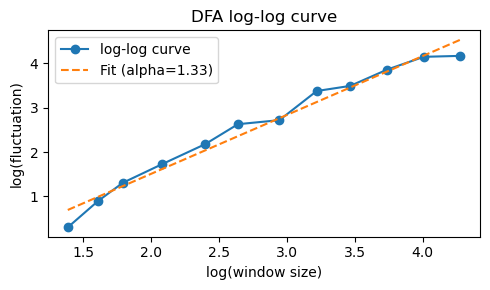

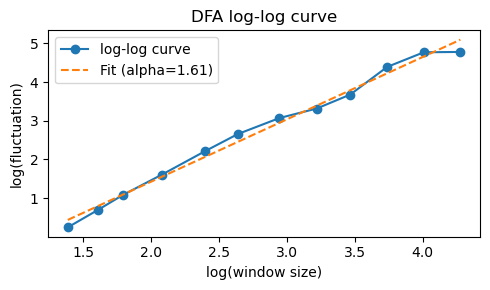

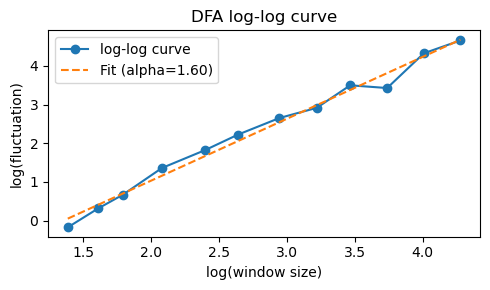

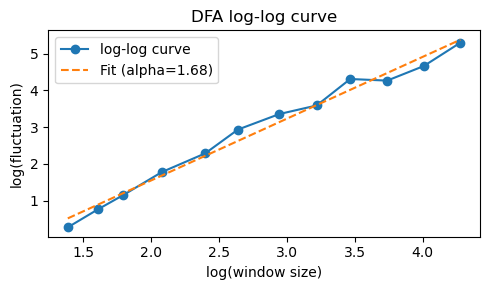

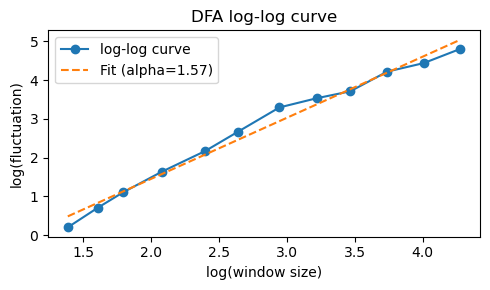

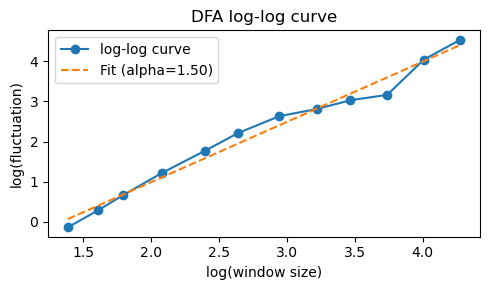

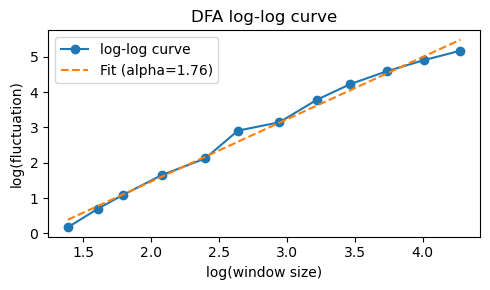

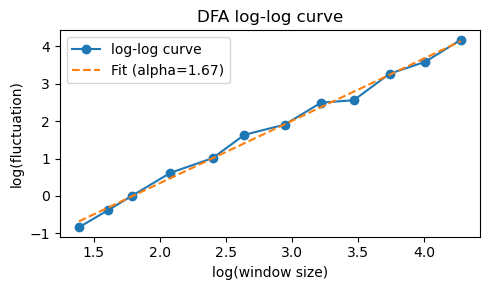

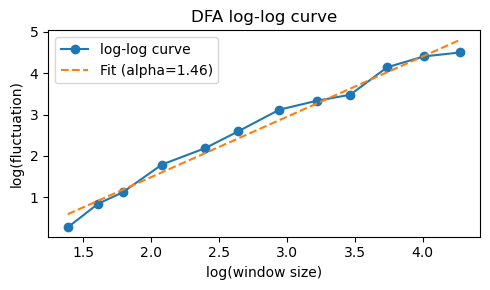

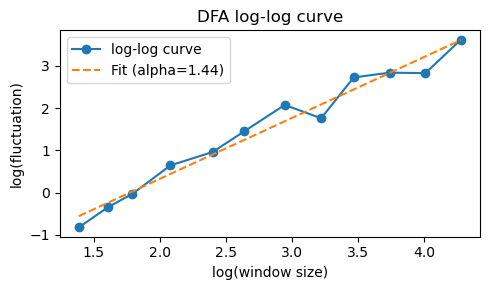

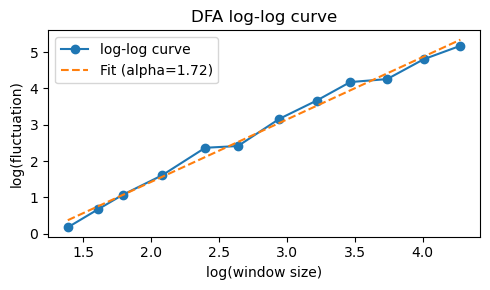

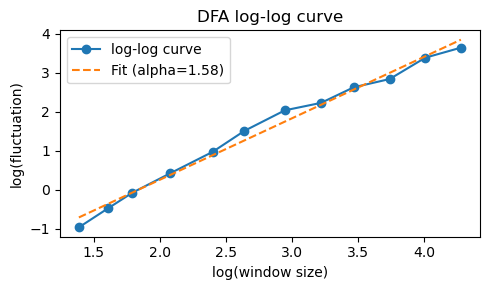

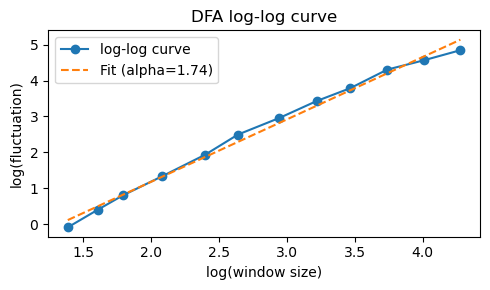

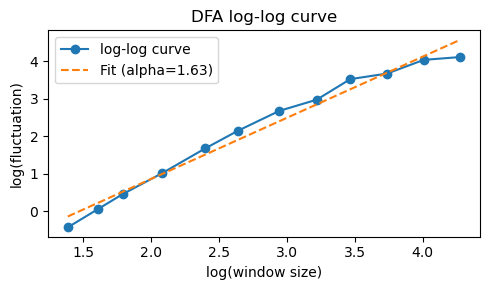

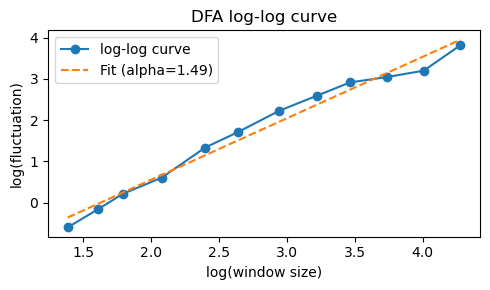

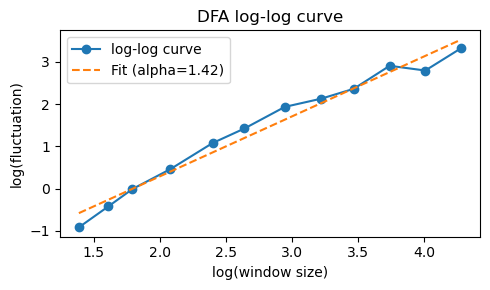

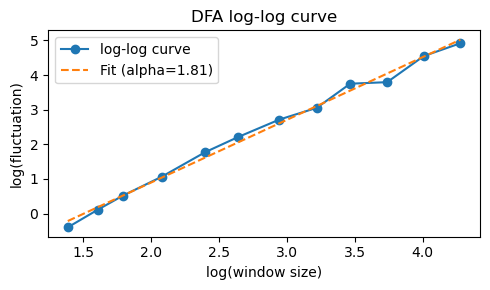

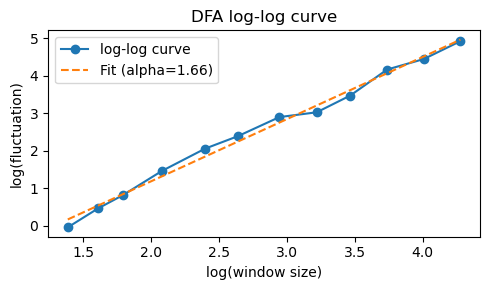

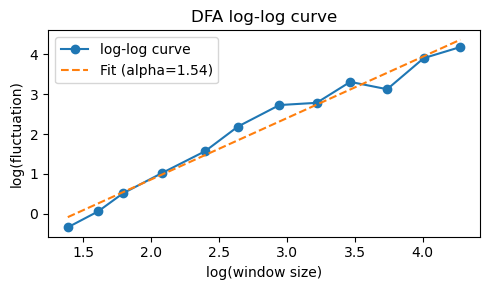

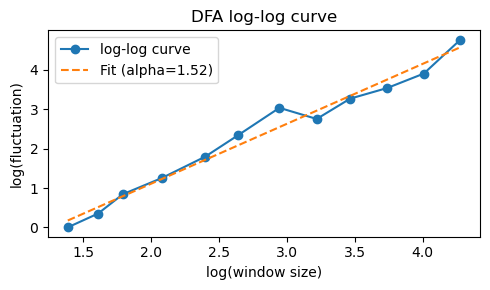

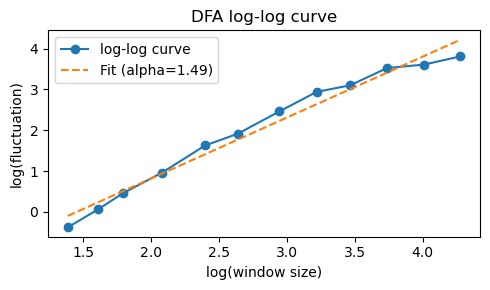

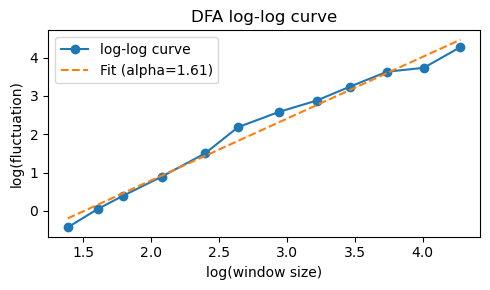

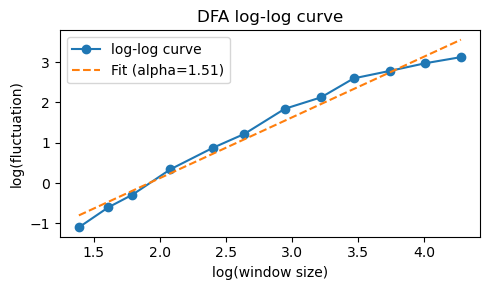

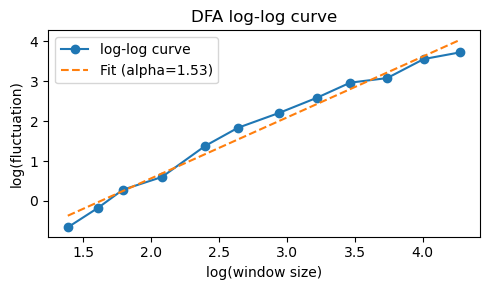

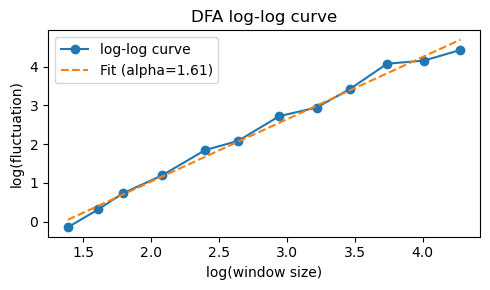

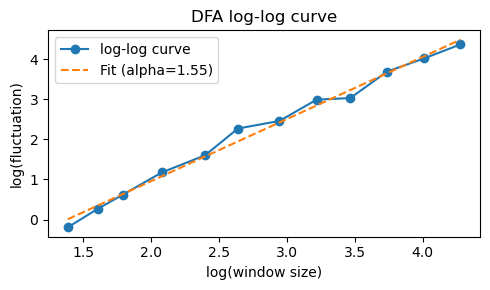

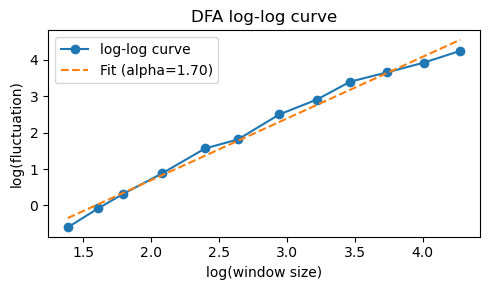

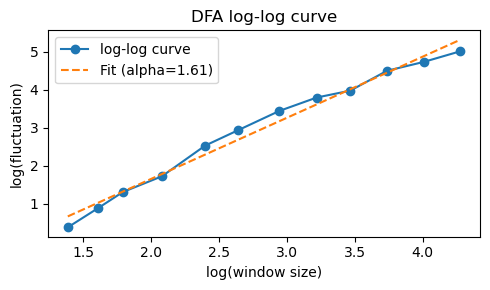

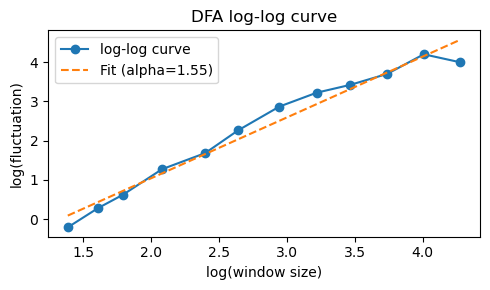

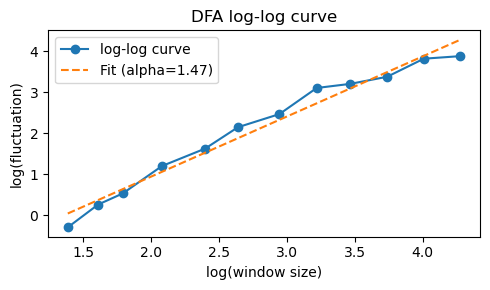

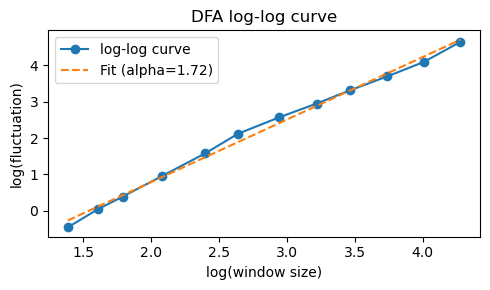

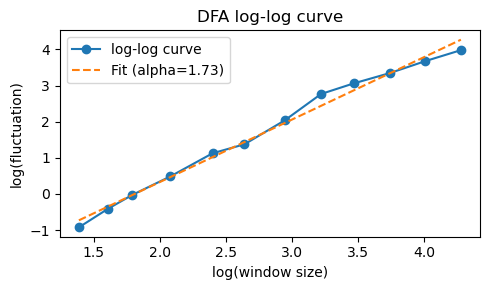

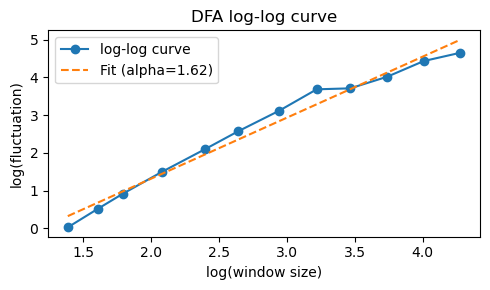

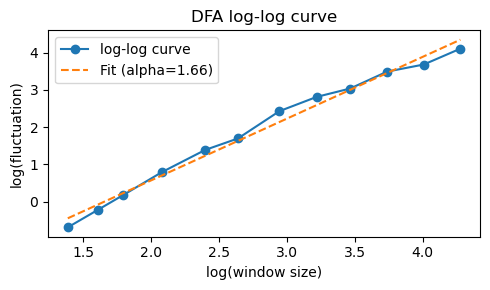

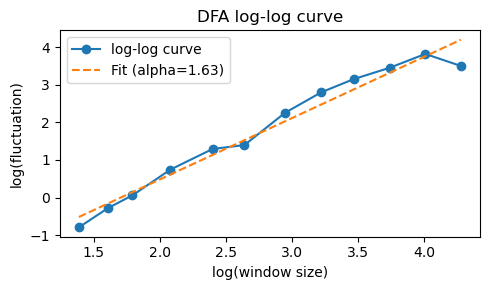

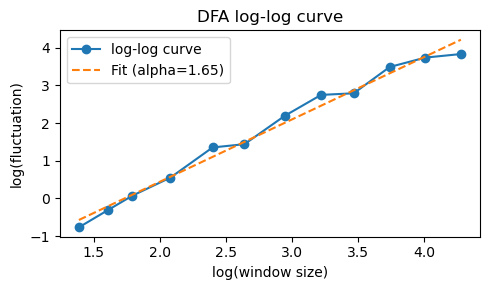

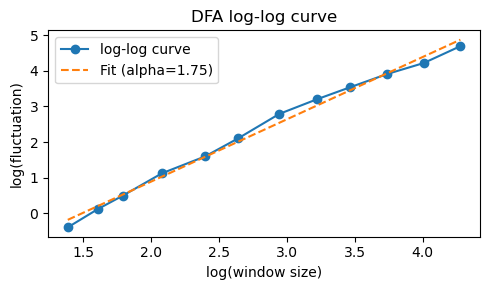

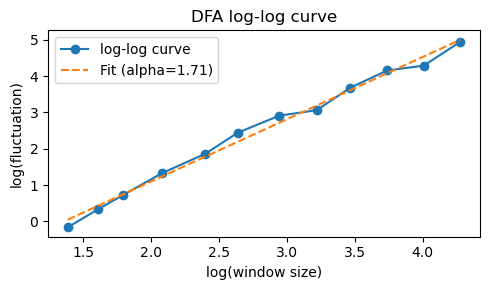

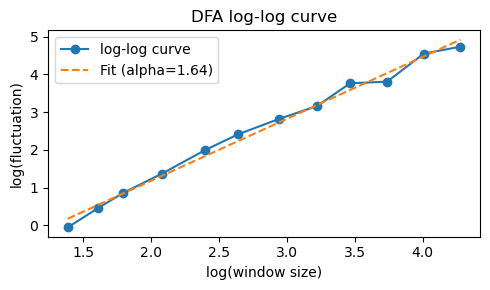

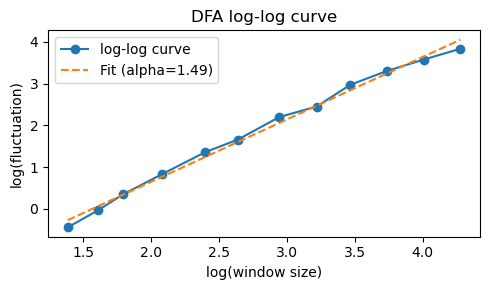

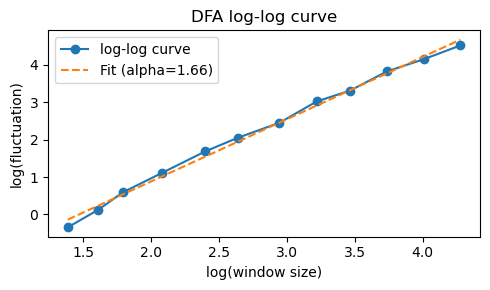

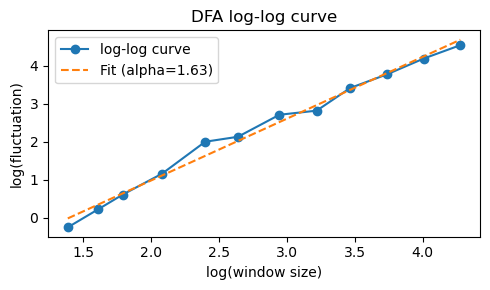

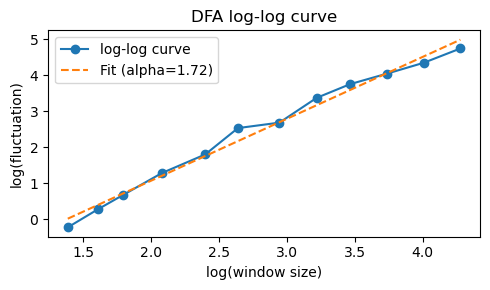

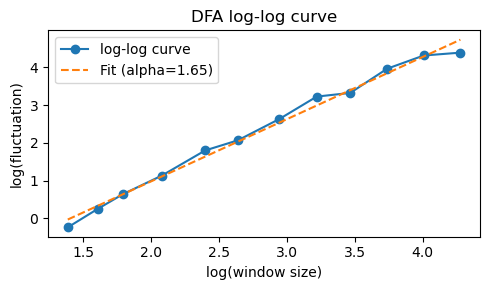

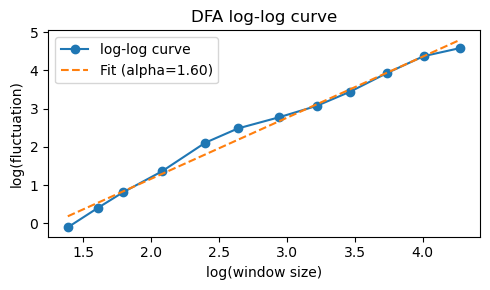

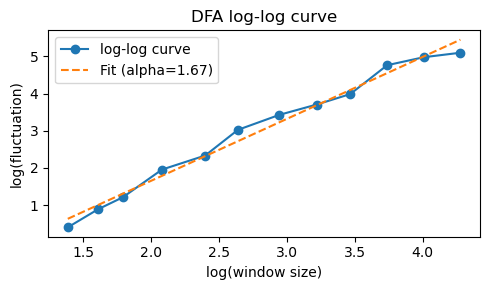

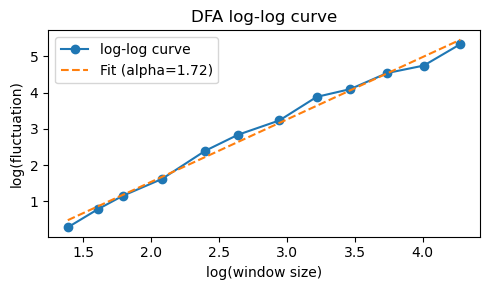

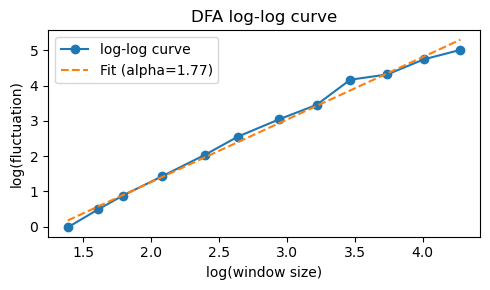

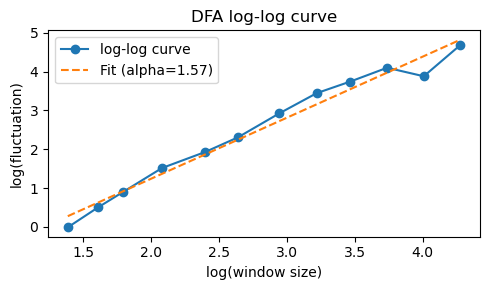

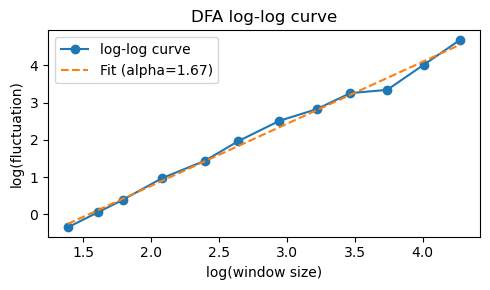

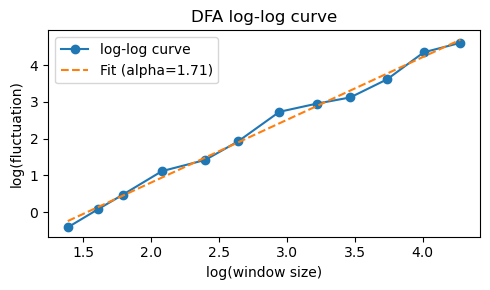

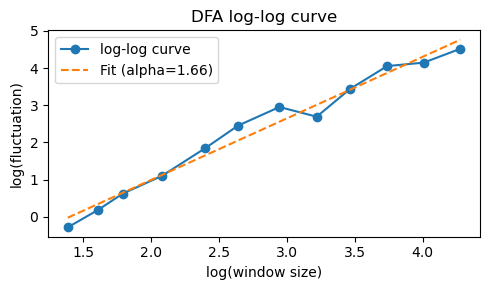

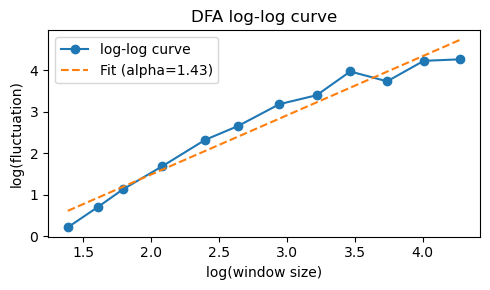

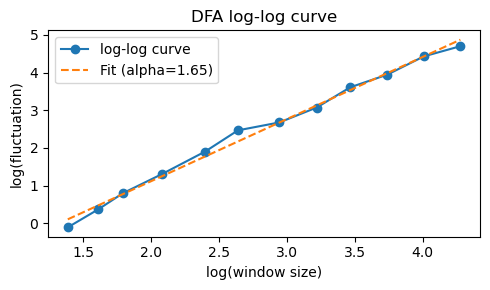

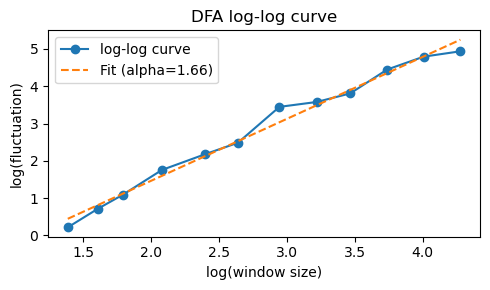

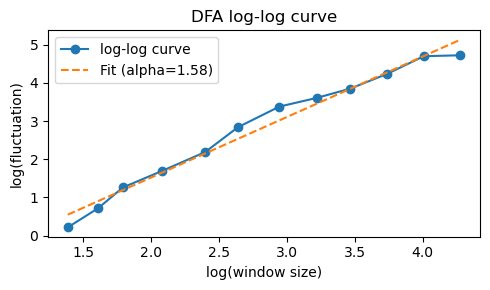

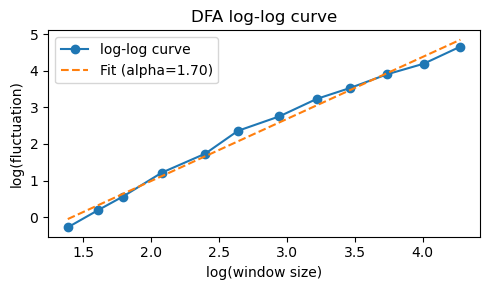

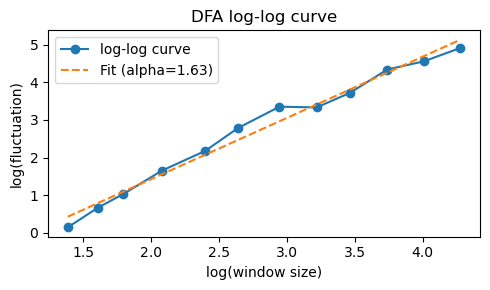

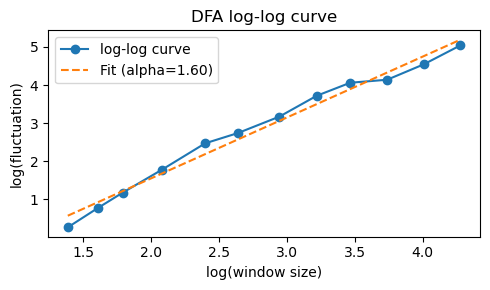

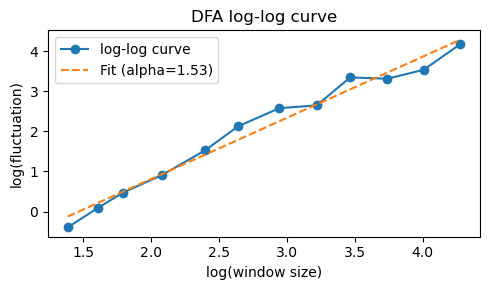

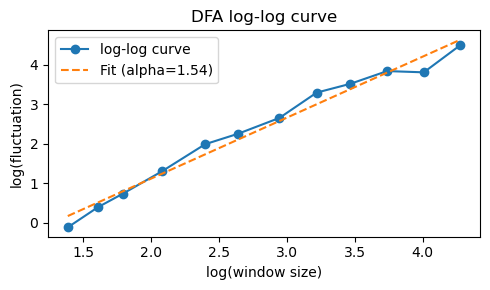

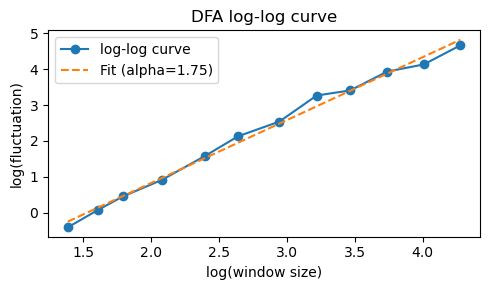

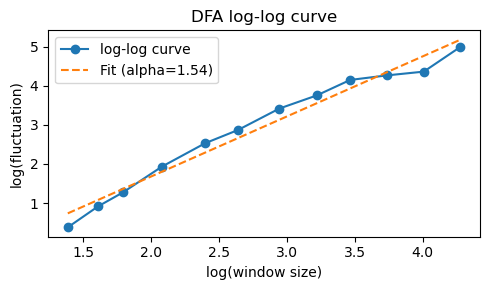

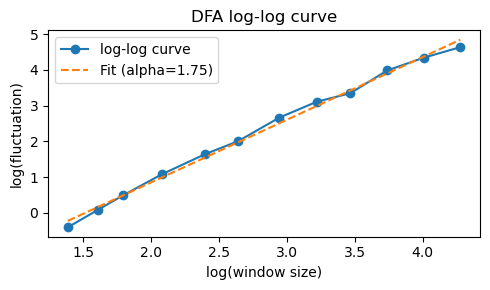

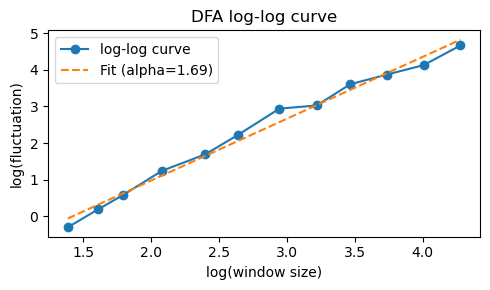

,case_id,mean,std,cv,min_glucose,max_glucose,range,mage,conga2,gfi,tu100,ao140,time_above_140,time_in_range,sd1,sd2,sampen,dfa_alpha
0,39,97.928819,9.459393,9.659457,81.0,123.0,42.0,NaN,13.924578,0.980836,70.486111,0.0,0.000000,100.000000,0.956552,13.325692,-0.399193,1.602772
1,98,96.887153,17.363312,17.921171,67.5,145.0,77.5,NaN,19.388705,1.533101,60.763889,18.0,1.736111,95.138889,1.427385,24.428183,-0.398186,1.577722
2,124,94.465278,10.254879,10.855713,78.0,124.0,46.0,NaN,11.655484,0.721254,82.986111,0.0,0.000000,100.000000,0.870697,14.403265,-0.399288,1.640572
3,54,101.071181,22.184434,21.949317,60.0,149.0,89.0,NaN,17.784928,1.365854,44.097222,62.5,3.819444,85.763889,1.188628,31.348042,-0.394538,1.670993
4,89,99.819444,15.594671,15.622879,74.0,142.0,68.0,NaN,16.257725,1.310105,55.555556,8.0,1.736111,98.263889,1.348410,21.990359,-0.399962,1.536427


In [ ]:
# 1. Compute DFA for all patients and integrate into metrics_df

dfa_results = []
for case_id, df in patients_interp.items():
    try:
        alpha, _, _ = dfa_full(df["glucose"])
        dfa_results.append({
            "case_id": case_id,
            "dfa_alpha": alpha
        })
    except Exception as e:
        dfa_results.append({
            "case_id": case_id,
            "dfa_alpha": None
        })

dfa_df = pd.DataFrame(dfa_results)
metrics_df = metrics_df.merge(dfa_df, on="case_id", how="left")
metrics_df.head()

**Nota sobre DFAraw vs DFAint:**

Two versions of DFA were considered conceptually (raw and integrated). In this implementation, the integrated version was used, as it is standard in time-series analysis.

In [54]:
# 3) Fix: detect long gaps ensuring datetime format

def detect_long_gaps(df, threshold_minutes=10):
    # Ensure the 'time' column is datetime
    time_col = pd.to_datetime(df["time"], errors="coerce")
    time_diff = time_col.diff()
    gaps = time_diff > pd.Timedelta(minutes=threshold_minutes)
    return gaps.sum()

# Recalculate and merge long gaps

gap_summary = []
for case_id, df in patients_interp.items():
    n_gaps = detect_long_gaps(df)
    gap_summary.append({
        "case_id": case_id,
        "long_gaps": n_gaps
    })

gaps_df = pd.DataFrame(gap_summary)
metrics_df = metrics_df.merge(gaps_df, on="case_id", how="left")
metrics_df.head()

,case_id,mean,std,cv,min_glucose,max_glucose,range,mage,conga2,gfi,tu100,ao140,time_above_140,time_in_range,sd1,sd2,sampen,dfa_alpha,long_gaps_x,long_gaps_y
0,39,97.928819,9.459393,9.659457,81.0,123.0,42.0,NaN,13.924578,0.980836,70.486111,0.0,0.000000,100.000000,0.956552,13.325692,-0.399193,1.602772,0,0
1,98,96.887153,17.363312,17.921171,67.5,145.0,77.5,NaN,19.388705,1.533101,60.763889,18.0,1.736111,95.138889,1.427385,24.428183,-0.398186,1.577722,0,0
2,124,94.465278,10.254879,10.855713,78.0,124.0,46.0,NaN,11.655484,0.721254,82.986111,0.0,0.000000,100.000000,0.870697,14.403265,-0.399288,1.640572,0,0
3,54,101.071181,22.184434,21.949317,60.0,149.0,89.0,NaN,17.784928,1.365854,44.097222,62.5,3.819444,85.763889,1.188628,31.348042,-0.394538,1.670993,0,0
4,89,99.819444,15.594671,15.622879,74.0,142.0,68.0,NaN,16.257725,1.310105,55.555556,8.0,1.736111,98.263889,1.348410,21.990359,-0.399962,1.536427,0,0


In [ ]:
# 4. Save the final complete result

final_df = metrics_df.merge(clinical, left_on="case_id", right_index=True)
final_df.to_csv("../results/tables/final_dataset.csv", index=False)
final_df.head()

,case_id,case_id_x,mean,std,cv,min_glucose,max_glucose,range,mage,conga2,...,dfa_alpha,long_gaps,case_id_y,gender,age,BMI,glycaemia,HbA1c,follow_up,T2DM
0,39,39,97.928819,9.459393,9.659457,81.0,123.0,42.0,NaN,13.924578,...,1.602772,0,40,0,61,29.9,108,5.3,679.0,FALSE
1,98,98,96.887153,17.363312,17.921171,67.5,145.0,77.5,NaN,19.388705,...,1.577722,0,100,1,53,22.2,80,NaN,1489.0,FALSE
2,124,124,94.465278,10.254879,10.855713,78.0,124.0,46.0,NaN,11.655484,...,1.640572,0,126,1,75,27.6,113,5.9,643.0,FALSE
3,54,54,101.071181,22.184434,21.949317,60.0,149.0,89.0,NaN,17.784928,...,1.670993,0,55,1,64,30.2,102,5.7,778.0,FALSE
4,89,89,99.819444,15.594671,15.622879,74.0,142.0,68.0,NaN,16.257725,...,1.536427,0,91,1,78,34.4,118,6.1,286.0,FALSE


In [53]:
# Final group analysis: DM2 vs no DM2

# Drop duplicate ID columns before analysis
cols_to_drop = [col for col in final_df.columns if col.startswith('case_id') and col != 'case_id']
final_df_clean = final_df.drop(columns=cols_to_drop)

# If 'DM2' is not in final_df_clean, create it from 'T2DM'
if "DM2" not in final_df_clean.columns and "T2DM" in final_df_clean.columns:
    final_df_clean["DM2"] = final_df_clean["T2DM"].map({"TRUE": 1, "FALSE": 0})

dm2 = final_df_clean[final_df_clean["DM2"] == 1]
no_dm2 = final_df_clean[final_df_clean["DM2"] == 0]

dm2_mean = dm2.mean(numeric_only=True)
no_dm2_mean = no_dm2.mean(numeric_only=True)

comparison = pd.DataFrame({
    "DM2": dm2_mean,
    "No_DM2": no_dm2_mean
})
comparison["difference"] = comparison["DM2"] - comparison["No_DM2"]
comparison

,DM2,No_DM2,difference
case_id,69.857143,95.289720,-25.432577
mean,103.630952,102.698809,0.932143
std,14.901017,14.599765,0.301252
cv,14.456496,14.158724,0.297772
min_glucose,75.357143,78.233645,-2.876502
max_glucose,144.642857,143.443925,1.198932
range,69.285714,65.210280,4.075434
mage,30.000000,8.750000,21.250000
conga2,18.302941,18.306084,-0.003143
gfi,1.259831,1.299000,-0.039170


In [ ]:
# Save group comparison
comparison.to_csv("../results/tables/group_comparison.csv")

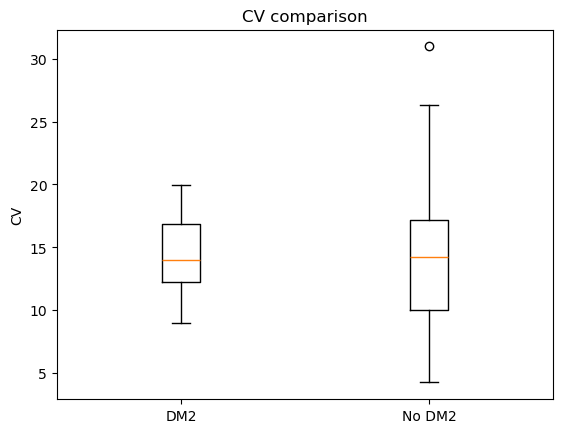

In [ ]:
# Comparative visualization: CV between groups
import matplotlib.pyplot as plt

plt.boxplot([
    dm2["cv"].dropna(),
    no_dm2["cv"].dropna()
])
plt.xticks([1,2], ["DM2", "No DM2"])
plt.title("CV comparison")
plt.ylabel("CV")
plt.show()

## Final Interpretation

The analysis shows that CGM-derived metrics capture meaningful differences in glucose dynamics between patients.

Variability metrics such as CV, MAGE, and CONGA reflect fluctuations in glucose levels, which are associated with metabolic instability.

The DFA exponent provides additional insight into temporal correlations, suggesting differences in glucose regulation patterns.

Patients with type 2 diabetes tend to exhibit higher variability and altered temporal structure compared to non-diabetic patients.

Overall, this study demonstrates that CGM metrics, including nonlinear measures, can be useful to characterize glucose dynamics and may help in identifying early signs of metabolic dysfunction.

## Summary of the full analysis performed

This notebook implements a comprehensive analysis of Continuous Glucose Monitoring (CGM) data to compare groups (T2DM vs non-T2DM) and characterize glucose dynamics. The main stages and results are:

- **Data loading and cleaning:**
  - Reading individual patient files.
  - Interpolation and handling of missing values.
  - Detection and reporting of long gaps and exclusions.

- **Metric computation:**
  - Conventional metrics: mean, standard deviation, coefficient of variation, minimum, maximum, range.
  - Variability metrics: MAGE, CONGA-2, Glycaemic Fluctuation Index (GFI).
  - Prediabetic phenotype metrics: time under 100 mg/dL (TU100), area over 140 mg/dL (AO140), time in range.
  - Entropy metrics: Approximate Entropy (ApEn), Sample Entropy (SampEn), and Poincaré (SD1, SD2).
  - Detrended Fluctuation Analysis (DFA): robust computation of DFAint and DFAraw for all patients.

- **Visualization:**
  - Glucose vs. time curves for individual patients, with reference bands.
  - Aggregated curves (median and percentiles) by group (T2DM vs non-T2DM).
  - Boxplots and visual comparisons of metrics between groups.

- **Reporting and exclusions:**
  - Summary table of metrics per patient.
  - Report of exclusion reasons (global missingness, long gaps, etc.).

- **Advanced analysis:**
  - Principal Component Analysis (PCA) on the metrics to explore correlations and group separation.
  - Statistical comparison of metrics between T2DM and non-T2DM groups.

- **Results export:**
  - Tables and figures exported for use in reports or publications.

This workflow enables robust characterization of glucose dynamics and clinical group comparisons, following best practices in biomedical data analysis.